<a href="https://colab.research.google.com/github/aaallyssaaa/MeSH_Lora/blob/main/Task1_Lora_v4.R1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 環境設定

In [ ]:
!pip install torchinfo

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# 準備資料集

In [ ]:
# 解壓縮檔案到指定資料夾
!tar -xzvf /content/ohsumed-first-20000-docs.tar.gz

串流輸出內容已截斷至最後 5000 行。
ohsumed-first-20000-docs/test/C15/0013282
ohsumed-first-20000-docs/test/C15/0013475
ohsumed-first-20000-docs/test/C15/0013532
ohsumed-first-20000-docs/test/C15/0013553
ohsumed-first-20000-docs/test/C15/0013555
ohsumed-first-20000-docs/test/C15/0013773
ohsumed-first-20000-docs/test/C15/0013799
ohsumed-first-20000-docs/test/C15/0013809
ohsumed-first-20000-docs/test/C15/0013846
ohsumed-first-20000-docs/test/C15/0013848
ohsumed-first-20000-docs/test/C15/0013971
ohsumed-first-20000-docs/test/C15/0014048
ohsumed-first-20000-docs/test/C15/0014052
ohsumed-first-20000-docs/test/C15/0014054
ohsumed-first-20000-docs/test/C15/0014055
ohsumed-first-20000-docs/test/C15/0014056
ohsumed-first-20000-docs/test/C15/0014058
ohsumed-first-20000-docs/test/C15/0014059
ohsumed-first-20000-docs/test/C15/0014071
ohsumed-first-20000-docs/test/C15/0014180
ohsumed-first-20000-docs/test/C15/0014237
ohsumed-first-20000-docs/test/C15/0014277
ohsumed-first-20000-docs/test/C15/0014288
ohsumed-first

In [ ]:
import os
import csv
import sys
import pandas as pd
def load_ohsumed_data(data_dir, split="training"):
    """
    Parse Ohsumed folder structure.
    Default structure: data_dir/training/category_folder/text_file
    """
    split_dir = os.path.join(data_dir, split)
    texts = []
    labels = []

    # Dynamically create category mapping (0 to 22)
    categories = sorted(os.listdir(split_dir))
    category_to_id = {cat: idx for idx, cat in enumerate(categories) if os.path.isdir(os.path.join(split_dir, cat))}

    for cat, label_id in category_to_id.items():
        cat_dir = os.path.join(split_dir, cat)
        for filename in os.listdir(cat_dir):
            filepath = os.path.join(cat_dir, filename)
            if os.path.isfile(filepath):
                with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                    texts.append(f.read())
                labels.append(label_id)

    return texts, labels
def create_dataset(root_dir, output_file):
    """
    Scans subdirectories of a root directory to create a CSV dataset.

    Each subdirectory is treated as a category (label). Each file within a
    subdirectory is a data sample, and its content is the feature (text).

    Args:
        root_dir (str): The path to the root directory containing category subdirectories.
        output_file (str): The name of the CSV file to be created.
    """
    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Root directory '{root_dir}' not found.")
        sys.exit(1)
    train_texts, train_labels = load_ohsumed_data(root_dir, split="training")
    test_texts, test_labels = load_ohsumed_data(root_dir, split="test")
    df_train = pd.DataFrame({"abstract": train_texts, "label": train_labels})
    df_test = pd.DataFrame({"abstract": test_texts, "label": test_labels})
    df = pd.concat([df_train, df_test], ignore_index=True)
    df = df.loc[~df.duplicated(subset='abstract', keep=False)]
    # Check if any data was collected
    if not len(df):
        print("No data was collected. The output file will not be created.")
        return

    # Write the collected data to a CSV file
    print(f"\nWriting {len(df)} records to {output_file}...")
    try:
        df.to_csv(output_file, index=False)
        print(f"Successfully created dataset: {output_file}")

    except IOError as e:
        print(f"Error writing to file {output_file}. Error: {e}")


if __name__ == '__main__':
    # The script assumes it's run from the 'ohsumed-all' directory's parent,
    # or you can specify the path directly.
    # We'll use '.' to indicate the current directory based on your context.
    current_directory = '/content/ohsumed-first-20000-docs'
    csv_filename = 'ohsumed_dataset.csv' # Corrected from 'ohsumed_dataset.csv'

    create_dataset(current_directory, csv_filename)


Writing 7400 records to ohsumed_dataset.csv...
Successfully created dataset: ohsumed_dataset.csv


In [ ]:
import pandas as pd

file_path = 'ohsumed_dataset.csv'

full_df = pd.read_csv(file_path)[['label', 'abstract']]

full_df['full_text'] = full_df['abstract'].fillna("")

print("資料讀取成功！前五筆資料如下：")
print(full_df.head())

資料讀取成功！前五筆資料如下：
   label                                           abstract  \
0      0  In vitro evaluation of nicotinamide riboside a...   
1      0  Group B streptococcus endocarditis following s...   
2      0  Streptococcus mitis sepsis in bone marrow tran...   
3      0  A resurgence of acute rheumatic fever in a mid...   
4      0  Air contamination in open heart surgery with d...   

                                           full_text  
0  In vitro evaluation of nicotinamide riboside a...  
1  Group B streptococcus endocarditis following s...  
2  Streptococcus mitis sepsis in bone marrow tran...  
3  A resurgence of acute rheumatic fever in a mid...  
4  Air contamination in open heart surgery with d...  


# 分類報告程式


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

def evaluate_per_class(model, dataloader, device, category_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(ids, mask)
            # 單分類邏輯：取機率最大的那一類
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 產生分類報告
    report = classification_report(all_labels, all_preds, target_names=category_names, zero_division=0)
    print("\n=== 每個分類的詳細準確度分析 ===")
    print(report)

# 訓練

In [ ]:
import torch
import time
import torch.nn as nn
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from peft import PeftModel
from torchinfo import summary
from huggingface_hub import HfApi, login, create_repo, hf_hub_download, notebook_login
import copy

# 1. 定義分類模型
class RobertaClassifier(nn.Module):
    def __init__(self, model_path_or_name, num_labels=23, freeze_backbone=True, useLoRA=False):
        super(RobertaClassifier, self).__init__()
        # 載入 RoBERTa
        self.roberta = RobertaModel.from_pretrained(model_path_or_name)
        # LoRA 掛載
        if useLoRA:
            LoRA_folder = "Alyssalai/RoBERTa_LoRA_v4"
            self.roberta = PeftModel.from_pretrained(self.roberta, LoRA_folder)
        # 凍結 RoBERTa 參數
        if freeze_backbone:
            for param in self.roberta.parameters():
                param.requires_grad = False

        # 定義分類層 (NN Head)
        self.classifier = nn.Sequential(
            nn.Linear(768, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

        # summary model
        print("base model：\n\n", summary(self.roberta))
        print("classifer NN Head：\n\n", summary(self.classifier))

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # 使用 CLS Token 的向量
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

# 2. 資料集處理
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

# 3. 訓練與評估主程式
def run_experiment(model_name_or_path, train_df, test_df, num_epochs=60, useLoRA=False, folder_name="default_model_name"):
    api = HfApi()
    username = api.whoami()['name']
    repo_id = f"{username}/{folder_name}"
    create_repo(repo_id, exist_ok=True)
    uploaded_checkpoints = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaClassifier(model_name_or_path, num_labels=23, useLoRA=useLoRA)

    # --- [初始化紀錄清單與累積時間] ---
    history = []
    total_time = 0

    # 自動續傳邏輯
    resume_epoch = 0
    try:
        repo_files = api.list_repo_tree(repo_id)
        ckpt_folders = [f.path for f in repo_files if "checkpoint-" in f.path]
        if ckpt_folders:
            resume_epoch = max([int(f.split('-')[-1]) for f in ckpt_folders])
            uploaded_checkpoints = sorted(ckpt_folders, key=lambda x: int(x.split('-')[-1]))

            # 下載權重
            ckpt_file = hf_hub_download(repo_id=repo_id, filename="pytorch_model.bin", subfolder=f"checkpoint-{resume_epoch}")
            model.load_state_dict(torch.load(ckpt_file, map_location=device))

            try:
                log_path = hf_hub_download(repo_id=repo_id, filename="training_history.csv")
                old_history_df = pd.read_csv(log_path)
                history = old_history_df.to_dict('records')
                total_time = history[-1]['cumulative_time_sec']
                print(f"成功載入舊日誌，目前已有 {len(history)} 筆紀錄，累積時間：{total_time:.2f}s")
            except:
                print("未偵測到舊日誌，將建立新紀錄")

            print(f"續傳成功：從 Epoch {resume_epoch+1} 開始")
    except Exception as e:
        print(f"初始化偵測進度時發生異常: {e}")

    model.to(device)

    # 資料分割與 Loader
    train_data, val_data = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
    train_loader = DataLoader(TextDataset(train_data['full_text'].tolist(), train_data['label'].tolist(), tokenizer), batch_size=32, shuffle=True)
    val_loader = DataLoader(TextDataset(val_data['full_text'].tolist(), val_data['label'].tolist(), tokenizer), batch_size=32)
    test_loader = DataLoader(TextDataset(test_df['full_text'].tolist(), test_df['label'].tolist(), tokenizer), batch_size=32)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    # --- [初始化 Early Stopping 變數] ---
    best_val_acc = 0.0
    patience = 6  # 如果連續 6 輪沒進步就停止
    counter = 0
    best_model_state = None

    # 訓練迴圈
    for epoch in range(resume_epoch, num_epochs):
        epoch_start = time.perf_counter()

        # Training
        model.train()
        train_preds, train_labels_current = [], []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            train_labels_current.extend(labels.cpu().numpy())

        # Validation
        model.eval()
        val_preds_current, val_labels_current = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                logits = model(ids, mask)
                val_preds_current.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_labels_current.extend(labels.cpu().numpy())

        epoch_end = time.perf_counter()
        duration = epoch_end - epoch_start
        total_time += duration

        t_acc = accuracy_score(train_labels_current, train_preds)
        v_acc = accuracy_score(val_labels_current, val_preds_current)

        # 儲存 Epoch 數據
        history.append({
            'epoch': epoch + 1,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'epoch_duration_sec': duration,
            'cumulative_time_sec': total_time
        })

        # --- [每輪同步 Checkpoint 與 CSV] ---
        curr_count = epoch + 1
        ckpt_dir = "./ckpt_tmp"
        os.makedirs(ckpt_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{ckpt_dir}/pytorch_model.bin")

        remote_f = f"checkpoint-{curr_count}"
        api.upload_folder(folder_path=ckpt_dir, repo_id=repo_id, path_in_repo=remote_f)
        uploaded_checkpoints.append(remote_f)

        # 即時更新雲端 CSV
        pd.DataFrame(history).to_csv("training_history.csv", index=False)
        api.upload_file(path_or_fileobj="training_history.csv", path_in_repo="training_history.csv", repo_id=repo_id)

        # 保持最新兩個版本
        if len(uploaded_checkpoints) > 2:
            old = uploaded_checkpoints.pop(0)
            try: api.delete_folder(path_in_repo=old, repo_id=repo_id)
            except: pass

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            counter = 0  # 重新計時
            #偵測到進步時，將當前模型權重 copy 一份存起來
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"有進步，目前最佳 Validation Accuracy: {best_val_acc:.4f}")

        else:
            counter += 1
            print(f"沒有進步，目前連續未進步次數: {counter}/{patience}")

            if counter >= patience:
                print(f"達到 Patience 限制 ({patience}次)，觸發 Early Stopping。")
                break

        print(f"Epoch {curr_count} - Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}, Time: {duration:.2f}s")

    print("\n--- 執行最終評估與模型上傳 ---")
    model.eval()
    final_val_preds, final_val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(ids, mask)
            final_val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            final_val_labels.extend(labels.cpu().numpy())

    if best_model_state is not None:
        print(f"訓練結束。正在還原至最佳模型 (Val Acc: {best_val_acc:.4f}) 以進行最終存檔。")
        model.load_state_dict(best_model_state)

    if resume_epoch < num_epochs:
        final_dir = "./final_model"
        os.makedirs(final_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{final_dir}/pytorch_model.bin")
        tokenizer.save_pretrained(final_dir)
        api.upload_folder(folder_path=final_dir, repo_id=repo_id, path_in_repo="final_model")

        pd.DataFrame(history).to_csv("training_history.csv", index=False)
        api.upload_file(path_or_fileobj="training_history.csv", path_in_repo="training_history.csv", repo_id=repo_id)
        print(f"所有資料已成功同步至: {repo_id}")
    else:
        print(f"目標 Epoch ({num_epochs}) 已達標，跳過模型更新。")

    print("\n--- 正在產生各類別詳細報告 ---")
    category_list = [str(i) for i in range(23)]
    evaluate_per_class(model, test_loader, device, category_list)

    return final_val_labels, final_val_preds

# 4. 執行區
if __name__ == "__main__":

    # 資料讀取
    file_path = 'ohsumed_dataset.csv'
    full_df = pd.read_csv(file_path)[['label', 'abstract']]

    full_df['full_text'] = full_df['abstract'].fillna("")

    # 分類標籤數字化
    unique_labels = sorted(full_df['label'].unique())
    label_to_id = {l: i for i, l in enumerate(unique_labels)}
    full_df['label'] = full_df['label'].map(label_to_id)


    # min_size = full_df['label'].value_counts().min()
    # full_df = full_df.groupby('label', group_keys=False).apply(
    #     lambda x: x.sample(n=min_size, random_state=42)
    # ).reset_index(drop=True)
    # -----------------------------

    # 分割訓練與測試
    train_df, test_df = train_test_split(
        full_df,
        test_size=0.2,
        random_state=42,
        stratify=full_df['label']
    )
    print(f"原始資料總筆數: {len(full_df)}")
    print(f"訓練集筆數: {len(train_df)} (約 80%)")
    print(f"測試集筆數: {len(test_df)} (約 20%)")

    # 執行實驗

    # 實驗 1: 使用 原版RoBERTa
    # print("Running Experiment with Base RoBERTa...")
    # run_experiment('roberta-base', train_df, test_df, folder_name = "RoBERTa_based")

    # 實驗 2: 使用 MLM
    # print("Running Experiment with Custom RoBERTa...")
    # run_experiment('maxbeettww/roberta-ohsumed-mlm', train_df, test_df, folder_name = "RoBERTa_MLM")

    # 實驗 3: 使用 LoRA
    print("Running Experiment with RoBERTa + LoRA...")
    val_labels, val_preds = run_experiment('roberta-base', train_df, test_df, useLoRA=True, folder_name="RoBERTa_LoRA_v4.1")
    category_names = [str(unique_labels[i]) for i in range(len(unique_labels))]

原始資料總筆數: 7400
訓練集筆數: 5920 (約 80%)
測試集筆數: 1480 (約 20%)
Running Experiment with RoBERTa + LoRA...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_model/pytorch_model.bin:  31%|###       |  160MB /  520MB            

No files have been modified since last commit. Skipping to prevent empty commit.


所有資料已成功同步至: Alyssalai/RoBERTa_LoRA_v4.1

--- 正在產生各類別詳細報告 ---

=== 每個分類的詳細準確度分析 ===
              precision    recall  f1-score   support

           0       0.69      0.72      0.70        43
           1       0.83      0.67      0.74        15
           2       0.88      0.70      0.78        10
           3       0.86      0.86      0.86       206
           4       0.67      0.70      0.69        44
           5       0.83      0.68      0.74        71
           6       0.70      0.54      0.61        13
           7       0.82      0.72      0.77        50
           8       0.64      0.69      0.67        13
           9       0.73      0.78      0.76       111
          10       0.88      0.88      0.88        25
          11       0.64      0.90      0.75        68
          12       0.90      0.67      0.76        39
          13       0.79      0.97      0.87       235
          14       0.93      0.50      0.65        26
          15       0.82      0.35      0.49        2

# 畫圖

正在從 Alyssalai/RoBERTa_LoRA_v4.1 下載訓練日誌...


training_history.csv: 0.00B [00:00, ?B/s]

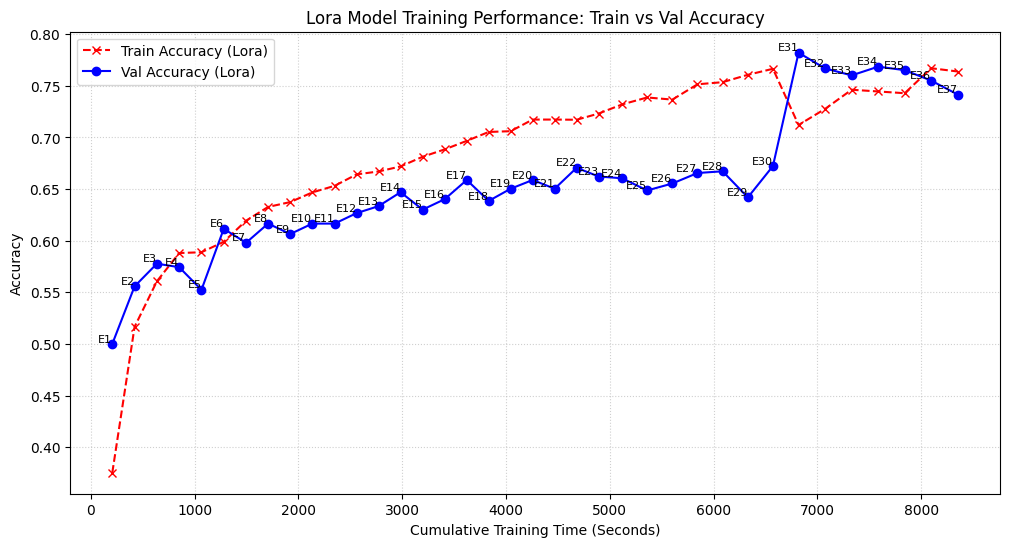

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# 1. 設定你的資訊
repo_id = "Alyssalai/RoBERTa_LoRA_v4.1"

try:
    # 2. 下載訓練歷史紀錄
    print(f"正在從 {repo_id} 下載訓練日誌...")
    log_path = hf_hub_download(repo_id=repo_id, filename="training_history.csv")
    df = pd.read_csv(log_path)

    # 3. 繪製圖表
    plt.figure(figsize=(12, 6))

    # 畫出訓練準確度 (紅色虛線)
    plt.plot(df['cumulative_time_sec'], df['train_acc'],
             marker='x', linestyle='--', color='r', label='Train Accuracy (Lora)')

    # 畫出驗證準確度 (藍色實線)
    plt.plot(df['cumulative_time_sec'], df['val_acc'],
             marker='o', linestyle='-', color='b', label='Val Accuracy (Lora)')

    # 4. 在點旁邊標註 Epoch (E1, E2...E30)
    for i, row in df.iterrows():
        plt.text(row['cumulative_time_sec'], row['val_acc'], f"E{int(row['epoch'])}",
                 fontsize=8, verticalalignment='bottom', horizontalalignment='right')

    # 圖表設定
    plt.title('Lora Model Training Performance: Train vs Val Accuracy')
    plt.xlabel('Cumulative Training Time (Seconds)')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # 顯示最佳準確度數值
    max_acc = df['val_acc'].max()
    max_epoch = df.loc[df['val_acc'].idxmax(), 'epoch']

    plt.show()

except Exception as e:
    print(f"繪圖失敗，請確認雲端是否有檔案：{e}")